# Multivariate, all for all

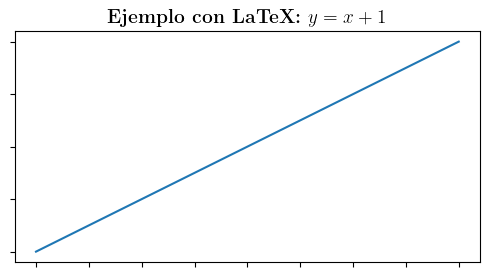

In [137]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- LaTeX rendering setup ---
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

# --- Example plot ---
fig, ax = plt.subplots(figsize=(6, 3))

ax.plot([0,1,2], [1,2,3])

# Title rendered with LaTeX fonts
ax.set_title(r"\textbf{Ejemplo con LaTeX:} $y = x + 1$", fontsize=14)

# Remove tick labels but keep axes
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.show()


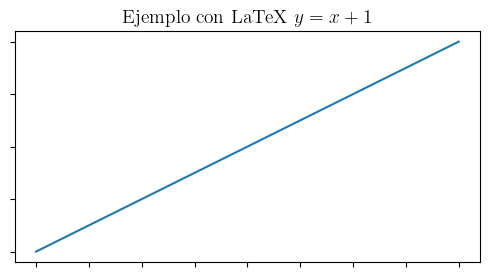

In [138]:
# --- Example plot ---
fig, ax = plt.subplots(figsize=(6, 3))

ax.plot([0,1,2], [1,2,3])

# Title rendered with LaTeX fonts
ax.set_title(r"Ejemplo con LaTeX $y = x + 1$", fontsize=14)

# Remove tick labels but keep axes
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.show()

# STARTER

In [1]:
import sys
import pathlib

# Get project root (parent of generation/)
project_root = pathlib.Path().resolve().parent
sys.path.insert(0, str(project_root))

# DATA
### Step 0: Data generation and scaling

In [2]:
from scripts.data_generation.binder import Binder
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scripts.data_generation.tsdg import DynamicalSystem
from sklearn.preprocessing import MinMaxScaler

# --- Data Generation ---
model_name = 'lorenz63'
sigma = 10 
beta = 8/3
rho = 28
params = (sigma, beta, rho)
binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
binder.import_module()      
model_fixed = binder.fixer()
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 1000)
y0 = np.array([0.1, 0.1, 0.1])
ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook = True)
_ = ds1.solve()

# --- Convert to dataframe ---
sample = ds1.to_dataframe()

# Train and Test Split
Full = sample.values
n_samples = len(Full)

train_size = int(0.60 * n_samples)   # 70% for training
val_size = int(0.20 * n_samples)     # 10% for validation
test_size = n_samples - train_size - val_size  # remaining 20% for testing

train_data = Full[:train_size]
val_data = Full[train_size:train_size+val_size]
test_data = Full[train_size+val_size:]

# --- Scaling ---
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

# # We fit on train but immediately transform test here for simplicity
# test_scaled  = scaler.transform(test_data.reshape(-1, 1)).flatten()
# # If you want the prediction back in original units:
# # yhat = scaler.inverse_transform(yhat_scaled)

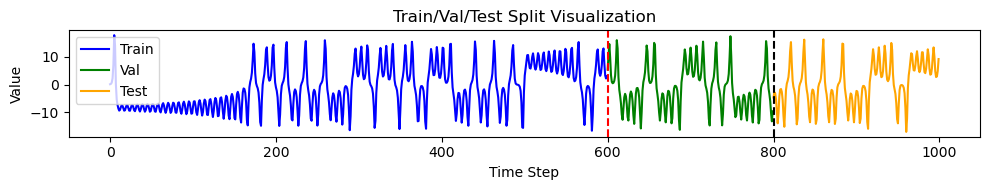

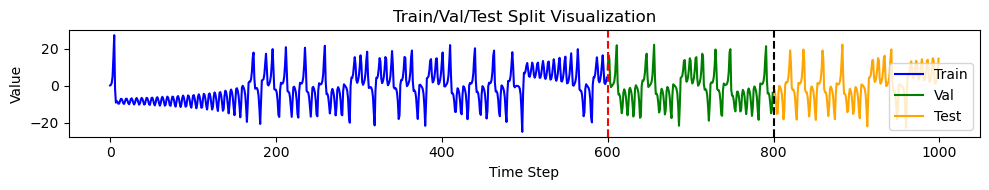

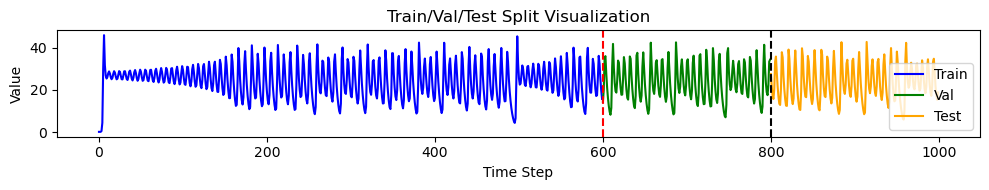

In [3]:
for i in range(len(sample.columns)):
    # Define x-axis ranges based on the lengths
    train_end = len(train_data[:,i])
    val_end = len(train_data[:,i]) + len(val_data[:,i])
    x_train = np.arange(train_end)
    x_val =np.arange(train_end, train_end + len(val_data[:,i]))
    x_test = np.arange(val_end, val_end + len(test_data[:,i]))
    # Plot
    plt.figure(figsize=(10, 2))
    plt.plot(x_train, train_data[:,i], label='Train', color='blue')
    plt.plot(x_val, val_data[:,i], label='Val', color='green')
    plt.plot(x_test, test_data[:,i], label='Test', color='orange')

    # Optional vertical line to indicate the split
    plt.axvline(x=train_end, color='red', linestyle='--') #label='Train/Test Split'
    plt.axvline(x=val_end, color='black', linestyle='--') #label='Train/Test Split'
    plt.legend()
    plt.title("Train/Val/Test Split Visualization")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

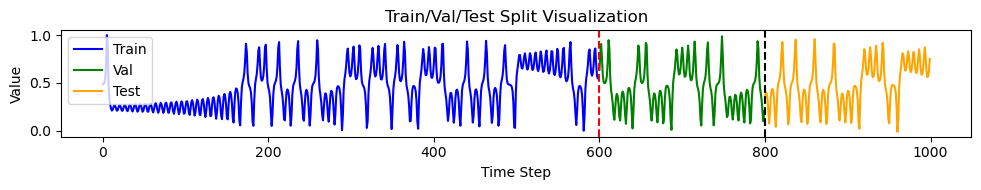

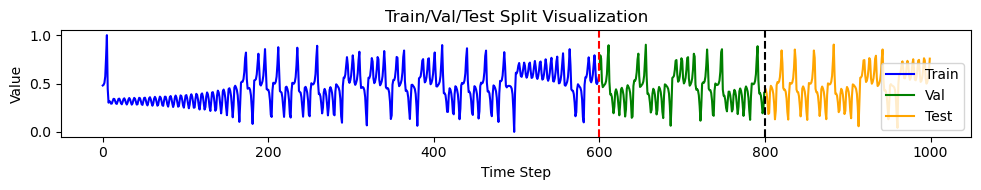

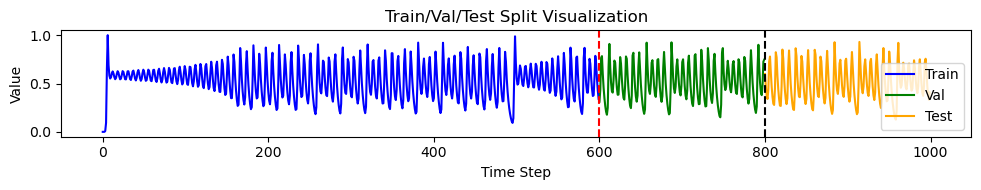

In [4]:
for i in range(len(sample.columns)):
    # Define x-axis ranges based on the lengths
    train_end = len(train_scaled[:,i])
    val_end = len(train_scaled[:,i]) + len(val_scaled[:,i])
    x_train = np.arange(train_end)
    x_val =np.arange(train_end, train_end + len(val_scaled[:,i]))
    x_test = np.arange(val_end, val_end + len(test_scaled[:,i]))
    # Plot
    plt.figure(figsize=(10, 2))
    plt.plot(x_train, train_scaled[:,i], label='Train', color='blue')
    plt.plot(x_val, val_scaled[:,i], label='Val', color='green')
    plt.plot(x_test, test_scaled[:,i], label='Test', color='orange')

    # Optional vertical line to indicate the split
    plt.axvline(x=train_end, color='red', linestyle='--') #label='Train/Test Split'
    plt.axvline(x=val_end, color='black', linestyle='--') #label='Train/Test Split'
    plt.legend()
    plt.title("Train/Val/Test Split Visualization")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

# Recursive

### Step 1: Data Preparation

In [ ]:
from numpy import array
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix, :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [7]:
# choose a number of time steps
n_steps_in, n_steps_out = 1, 1
# convert into input/output
X, y = split_sequences(train_scaled, n_steps_in, n_steps_out)

In [8]:
X.shape

(599, 1, 3)

In [9]:
for i in range(len(X)):
    print(X[i], y[i])

[[4.86447589e-01 4.79738719e-01 4.30745881e-04]] [[0.48986985 0.48666957 0.        ]]
[[0.48986985 0.48666957 0.        ]] [[5.03822071e-01 5.06901295e-01 4.17611642e-04]]
[[5.03822071e-01 5.06901295e-01 4.17611642e-04]] [[0.54943381 0.57203917 0.0087363 ]]
[[0.54943381 0.57203917 0.0087363 ]] [[0.69215139 0.76680912 0.09389267]]
[[0.69215139 0.76680912 0.09389267]] [[1.         1.         0.65089077]]
[[1.         1.         0.65089077]] [[0.89023684 0.44427998 1.        ]]
[[0.89023684 0.44427998 1.        ]] [[0.48449624 0.30205179 0.68967235]]
[[0.48449624 0.30205179 0.68967235]] [[0.32638191 0.31964645 0.5822419 ]]
[[0.32638191 0.31964645 0.5822419 ]] [[0.27010655 0.30984922 0.55180352]]
[[0.27010655 0.30984922 0.55180352]] [[0.23275226 0.29136512 0.56664925]]
[[0.23275226 0.29136512 0.56664925]] [[0.21071621 0.29309198 0.60586776]]
[[0.21071621 0.29309198 0.60586776]] [[0.21951638 0.31932111 0.62521321]]
[[0.21951638 0.31932111 0.62521321]] [[0.24822641 0.34168584 0.60394612]]
[[

# DIRECT-MULTIVARIATE-ALL_FOR_ALL

In [20]:
# split a multivariate sequence into samples
def split_sequences_v1(sequences, n_steps_in, n_steps_out, skip):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences) - skip:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[skip + end_ix:out_end_ix + skip , :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

Lorenz data

In [ ]:
n_steps_in = 1
n_steps_out = 1
horizon = 20
datasets = {}
for i in range(horizon):
    skip = i
    X, y = split_sequences_v1(train_scaled, n_steps_in, n_steps_out, skip)
    X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))
    datasets[i] = (X, y)  # store as tuple

Made Up Data

In [45]:
from numpy import array
# define input sequence
in_seq1 = array([i for i in range(0, 10, 1)])
in_seq2 = array([i for i in range(0, 20, 2)])

In [46]:
in_seq1

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [47]:
in_seq2

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [48]:
out_seq = array([in_seq1[i] + in_seq2[i] for i in range(len(in_seq1))])

In [49]:
from numpy import hstack
# convert to [row, columns] structure

in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))

#horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))

In [50]:
dataset

array([[ 0,  0,  0],
       [ 1,  2,  3],
       [ 2,  4,  6],
       [ 3,  6,  9],
       [ 4,  8, 12],
       [ 5, 10, 15],
       [ 6, 12, 18],
       [ 7, 14, 21],
       [ 8, 16, 24],
       [ 9, 18, 27]])

In [61]:
n_steps_in = 1
n_steps_out = 1
horizon = 4
datasets = {}
for i in range(horizon):
    skip = i 
    X, y = split_sequences_v1(dataset, n_steps_in, n_steps_out, skip)
    X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))
    datasets[i] = (X, y)  # store as tuple

In [62]:
for i in datasets:
    print(i, end=' ')

0 1 2 3 

In [65]:
X, y = datasets[3
            ]
print(X.shape)
print(y.shape)
for xi, yi in zip(X, y):
    print(xi,yi)

(6, 1, 3)
(6, 1, 3)
[[0 0 0]] [[ 4  8 12]]
[[1 2 3]] [[ 5 10 15]]
[[2 4 6]] [[ 6 12 18]]
[[3 6 9]] [[ 7 14 21]]
[[ 4  8 12]] [[ 8 16 24]]
[[ 5 10 15]] [[ 9 18 27]]


# DIREC-MULTIVARIATE-ALL_FOR_ALL
Dividir el horizonte $H$ en bloques $B$ de modo que $H/B = N$. Se entrena un modelo para predecir $B$ pasos, y la predicción del bloque se reutiliza como entrada del siguiente bloque hasta alcanzar $H$. 

In [ ]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix, :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [ ]:
# # choose a number of time steps
# n_steps_in, n_steps_out = 2, 2
# # convert into input/output
# X, y = split_sequences(train_scaled, n_steps_in, n_steps_out)

# choose a number of time steps
n_steps_in, n_steps_out = 2, 2
# convert into input/output
X, y = split_sequences(dataset, n_steps_in, n_steps_out)

In [67]:
for i in range(len(X)):
    print(X[i], y[i])

[[0 0 0]
 [1 2 3]] [[2 4 6]
 [3 6 9]]
[[1 2 3]
 [2 4 6]] [[ 3  6  9]
 [ 4  8 12]]
[[2 4 6]
 [3 6 9]] [[ 4  8 12]
 [ 5 10 15]]
[[ 3  6  9]
 [ 4  8 12]] [[ 5 10 15]
 [ 6 12 18]]
[[ 4  8 12]
 [ 5 10 15]] [[ 6 12 18]
 [ 7 14 21]]
[[ 5 10 15]
 [ 6 12 18]] [[ 7 14 21]
 [ 8 16 24]]
[[ 6 12 18]
 [ 7 14 21]] [[ 8 16 24]
 [ 9 18 27]]


# MIMO-MULTIVARIATE-ALL_FOR_ALL

In [ ]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix, :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [282]:
# choose a number of time steps
n_steps_in, n_steps_out = 20, 20
# convert into input/output
X, y = split_sequences(test_scaled, n_steps_in, n_steps_out)

In [ ]:
for i in range(len(X)):
        # ---------------------------

        # Inputs: concave upward
    print(X[i], y[i])

[[0.34753992 0.45374765 0.59827905]
 [0.40194509 0.43482175 0.46849719]
 [0.39118066 0.39351481 0.37643233]
 [0.32763923 0.31266264 0.3403495 ]
 [0.19736059 0.18552764 0.43955911]
 [0.07758895 0.19365707 0.7267321 ]
 [0.18592066 0.41147511 0.77894921]
 [0.35911786 0.47644428 0.61225437]
 [0.43018844 0.46245787 0.47006284]
 [0.43622611 0.43790884 0.36393055]
 [0.40500213 0.39210149 0.29144302]
 [0.32153987 0.29063314 0.27855921]
 [0.15351502 0.13006804 0.44936847]
 [0.04144834 0.22062651 0.82369322]
 [0.23956545 0.48309182 0.77035246]
 [0.4258563  0.51457162 0.57601581]
 [0.49293609 0.50798839 0.43869853]
 [0.52159613 0.52153887 0.33867037]
 [0.56172516 0.56734414 0.27199902]
 [0.6526745  0.67645505 0.26849431]] [[0.83212894 0.8422737  0.46947661]
 [0.92744307 0.71141413 0.85103459]
 [0.70476579 0.45540559 0.75708462]
 [0.52384983 0.43417559 0.56367645]
 [0.45957853 0.4370129  0.43099192]
 [0.42465117 0.41291829 0.33723808]
 [0.36613946 0.34491714 0.28736964]
 [0.24064657 0.20612173 0.3

# DIRMO-MULTIVARIATE-ALL_FOR_ALL
Dividir el horizonte $H$ en bloques $B$ de modo que $H/B = N$, y entrenar $N$ modelos, cada uno encargado de predecir $B$ pasos consecutivos. 

In [68]:
# split a multivariate sequence into samples
def split_sequences_v1(sequences, n_steps_in, n_steps_out, skip):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences)-skip:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[skip + end_ix:out_end_ix + skip , :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [69]:
n_steps_in = 1
n_steps_out = 2
horizon = 4
skip = n_steps_out
datasets = {}
for i in range(0, horizon, skip):
    X, y = split_sequences_v1(dataset, n_steps_in, n_steps_out, i)
    if len(X) == 0:
        raise ValueError(f"Insufficient data points for skip={i}.")
    #X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))
    datasets[i] = (X, y)  # store as tuple

In [70]:
for i in datasets:
    print(i, end=' ')

0 2 

In [75]:
X, y = datasets[0]
print(X.shape)
print(y.shape)
for xi, yi in zip(X, y):
    print(xi,yi)

(8, 1, 3)
(8, 2, 3)
[[0 0 0]] [[1 2 3]
 [2 4 6]]
[[1 2 3]] [[2 4 6]
 [3 6 9]]
[[2 4 6]] [[ 3  6  9]
 [ 4  8 12]]
[[3 6 9]] [[ 4  8 12]
 [ 5 10 15]]
[[ 4  8 12]] [[ 5 10 15]
 [ 6 12 18]]
[[ 5 10 15]] [[ 6 12 18]
 [ 7 14 21]]
[[ 6 12 18]] [[ 7 14 21]
 [ 8 16 24]]
[[ 7 14 21]] [[ 8 16 24]
 [ 9 18 27]]


# The Grand Unifycation (A1)

In [1]:
import numpy as np

def split_sequences_core(sequences, n_steps_in, n_steps_out, offset=0):
    X, y = [], []
    T = len(sequences)

    for i in range(T):
        x_start = i
        x_end   = i + n_steps_in

        y_start = x_end + offset
        y_end   = y_start + n_steps_out

        if y_end > T:
            break

        X.append(sequences[x_start:x_end, :])
        y.append(sequences[y_start:y_end, :])

    return np.array(X), np.array(y)


### Recursive

In [ ]:
X, y = split_sequences_core(
    train_scaled,
    n_steps_in=1,
    n_steps_out=1,
    offset=0
)

### Direc

In [ ]:
X, y = split_sequences_core(
    train_scaled,
    n_steps_in=2,
    n_steps_out=2,
    offset=0
)

### MIMO

In [ ]:
X, y = split_sequences_core(
    train_scaled,
    n_steps_in=20,
    n_steps_out=20,
    offset=0
)

### Direct

In [ ]:
def make_direct_datasets(sequences, n_steps_in, n_steps_out, horizon):
    datasets = {}
    for h in range(horizon):
        X, y = split_sequences_core(
            sequences,
            n_steps_in,
            n_steps_out,
            offset=h
        )
        datasets[h] = (X, y)
    return datasets

In [ ]:
datasets = make_direct_datasets(
    train_scaled,
    n_steps_in=1,
    n_steps_out=1,
    horizon=20
)

### DirMO

In [ ]:
def make_dirmo_datasets(sequences, n_steps_in, n_steps_out, horizon):
    datasets = {}
    for h in range(0, horizon, n_steps_out):
        X, y = split_sequences_core(
            sequences,
            n_steps_in,
            n_steps_out,
            offset=h
        )
        if len(X) == 0:
            raise ValueError(f"Insufficient data for offset={h}")
        datasets[h] = (X, y)
    return datasets

In [ ]:
datasets = make_dirmo_datasets(
    sequences=train_scaled,
    n_steps_in=10,
    n_steps_out=3,
    horizon=12
)